In [2]:
import random
import math
import numpy as np
import copy
import matplotlib.pyplot as plt
from collections import defaultdict

def print_matrix(M):
    for row in M:
        row_rounded = [round(x, 2) for x in row]
        row_no_negative_zeros = [0.0 if math.isclose(x, 0.0) else x for x in row_rounded]
        print(" ".join(f"{x:.2f}" for x in row_no_negative_zeros))
    print()


def divide_row(row, k, M):
    n = len(M)
    for j in range(n):
        M[row][j] /= k


def swap_rows(row1, row2, M):
    n = len(M)
    for j in range(n):
        M[row1][j], M[row2][j] = M[row2][j], M[row1][j]


def add_scaled_row_to_another(row1, row2, k, M):
    n = len(M)
    for j in range(n):
        M[row2][j] += M[row1][j] * k


def gauss_elimination(M, pivoting = True, normalize = True):
    n = len(M)

    for j in range(n): 
        if pivoting:
            maxi, pivot_idx = 0.0, 0
            for i in range(j, n):
                if abs(M[i][j]) > maxi :
                    maxi, pivot_idx = abs(M[i][j]), i
            if pivot_idx != j: # we need to swap
                swap_rows(j, pivot_idx, M)
        if normalize:
            divide_row(j, M[j][j], M) # we want our row to have 1.0 as the element on the diagonal

        for k in range(j + 1, n):
            assert not np.isclose(M[j][j], 0)
            add_scaled_row_to_another(j, k, -M[k][j]/M[j][j], M) 


def inverse_matrix(M):
    n = len(M)
    M_res = [[0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        M_res[i][i] = 1
    
    for j in range(n):
        maxi, pivot_idx = 0.0, 0 
        for i in range(j, n):
            if abs(M[i][j]) > maxi :
                maxi, pivot_idx = abs(M[i][j]), i 

        if pivot_idx != j:
            swap_rows(j, pivot_idx, M)
            swap_rows(j, pivot_idx, M_res)

        div = M[j][j]
        divide_row(j, div, M) 
        divide_row(j, div, M_res)

        for k in range(n):
            if k != j:
                scalar = -M[k][j]
                add_scaled_row_to_another(j, k, scalar, M) 
                add_scaled_row_to_another(j, k, scalar, M_res)

    return M_res



n = 6
M1 = [[random.randint(0, 15) for _ in range(n)] for _ in range(n)]
M2 = copy.deepcopy(M1)


print()
print_matrix(M1)
print("\nAFTER GAUSS ELIMINATION:\n")
gauss_elimination(M1)
print_matrix(M1)


if np.linalg.det(np.array(M2)) != 0:
    print("\nINVERSE MATRIX\n")
    print_matrix(inverse_matrix(M2))


2.00 6.00 12.00 6.00 5.00 0.00
10.00 0.00 11.00 9.00 0.00 1.00
3.00 15.00 0.00 15.00 6.00 1.00
6.00 2.00 4.00 4.00 9.00 8.00
4.00 12.00 5.00 9.00 10.00 8.00
11.00 15.00 15.00 4.00 6.00 0.00


AFTER GAUSS ELIMINATION:

1.00 1.36 1.36 0.36 0.55 0.00
0.00 1.00 0.19 -0.39 0.40 -0.07
0.00 0.00 1.00 0.76 0.30 0.03
0.00 0.00 0.00 1.00 0.08 0.09
0.00 0.00 0.00 0.00 1.00 0.84
0.00 0.00 0.00 0.00 0.00 1.00


INVERSE MATRIX

-0.09 0.02 0.04 0.09 -0.10 0.06
-0.05 -0.01 -0.02 -0.10 0.10 0.04
0.06 0.03 -0.06 -0.06 0.07 -0.01
0.03 0.05 0.05 -0.01 -0.01 -0.05
0.11 -0.11 0.10 0.24 -0.24 0.01
-0.09 0.08 -0.13 -0.15 0.28 -0.04



In [3]:
def gauss_numpy(A, pivoting = True, normalize = True, b = None):
    n = len(A)
    A = np.array(A, dtype=np.float64)
    if b is not None:
        b = np.array(b, dtype=np.float64)

    for i in range(n):
        if pivoting or np.isclose(A[i, i], 0.0):
            if pivoting:
                pivot_idx = i + np.argmax(np.abs(A[i:, i]))
            else:
                try:
                    pivot_idx = i + np.where(~np.isclose(np.abs(A[i:, i]), 0.0))[0][0]
                except IndexError:
                    print("No nonzero found in column\n", A[i:, i])
            
            if pivot_idx != i:
                A[[i, pivot_idx]] = A[[pivot_idx, i]]
                if b is not None:
                    b[i], b[pivot_idx] = b[pivot_idx], b[i]

        assert not np.isclose(A[i, i], 0.0)

        if normalize:
            pivot_val = A[i, i]
            A[i, :] /= pivot_val
            if b is not None:
                b[i] /= pivot_val

        for j in range(i+1, n):
            factor = A[j][i]/A[i, i]
            A[j, :] -= factor * A[i, :]
            if b is not None:
                b[j] -= factor * b[i]
    return A, b


def back_substitution(U:np.ndarray, b:np.ndarray):
    x = np.zeros_like(b)
    nn = U.shape[0]
    for i in range(nn-1, -1, -1):
        x[i] = (b[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
    return x


def lu_factorization(A, pivoting = True):
    n = len(A)
    P = [i for i in range(n)]
    A = np.array(A, dtype=np.float32)
    L, U = np.array([[0.0 for _ in range(n)] for _ in range(n)]), np.copy(A)
    for i in range(n):
        L[i, i] = 1.0
    for i in range(n):
        
        if pivoting or np.isclose(U[i, i], 0.0):
            if pivoting:
                pivot_idx = i + np.argmax(np.abs(U[i:, i]))
            else:
                pivot_idx = i + np.where(~np.isclose(np.abs(U[i:, i]), 0.0))[0][0]
        
            if pivot_idx != i:
                U[[i, pivot_idx]] = U[[pivot_idx, i]]
                L[[i, pivot_idx], :i] = L[[pivot_idx, i], :i]
                P[i], P[pivot_idx] = P[pivot_idx], P[i]

            assert not np.isclose(U[i, i], 0.0)

        for j in range(i+1, n):
            factor = U[j][i]/U[i, i]
            U[j, :] -= factor * U[i, :]
            L[j, i] = factor

    P = np.array(P)
    P_res = np.zeros((P.size, P.max() + 1))
    P_res[np.arange(P.size), P] = 1
    return P_res, L , U


def assert_l_matrix(L, tol):
    identity = np.eye(L.shape[0])
    L_tr = np.triu(L) # eliminates nonzero elements of upper diagonal part
    assert np.allclose(L_tr - identity, np.zeros_like(L), atol = tol) # checks ones on diagonal


def assert_u_matrix(U, tol, has_ones = False):
    U_tr = np.tril(U, (-1 if not has_ones else 0) )
    if has_ones:
        U_tr -= np.eye(U.shape[0])
    assert np.allclose(U_tr, 0, atol=tol)


In [ ]:
NUM_TRIALS = 10000
n = 40

lu_pivot_diff = defaultdict(list)
with_error, without_error = 0, 0
for i in range(NUM_TRIALS):
    if i % (NUM_TRIALS//50) == 0:
        print(i, end = ' ')
    M3 = [[random.random() * 10 for _ in range(n)] for _ in range(n)]
    M3 = np.array(M3)
    P2, L2, U2 = lu_factorization(M3)
    P3, L3, U3 = lu_factorization(M3, False)

    for j, (Lj, Uj, tol) in enumerate([[L2, U2, 5e-6], [L3, U3, 2e-2]]):
        try:
            assert_l_matrix(Lj, tol)
            assert_u_matrix(Uj, tol)
        except Exception as e:
            if j == 0:
                with_error += 1
            else:
                without_error += 1

    for func, label in [[lambda x: np.max(np.abs(x)), "max"], [lambda x: np.mean(x), "mean"],
        [lambda x: np.median(x), "median"]]:

        pivot, no_pivot = func(P2 @ M3 - L2 @ U2), func(P3 @ M3 - L3 @ U3)
        
        if pivot == 0:
            if no_pivot == 0:
                diff_i = 1
            else:
                print(f"Pivot is zero but no pivot is not: {no_pivot}")
                diff_i = no_pivot/np.finfo(np.float64).tiny
        else:
            diff_i = no_pivot/pivot

        lu_pivot_diff[label].append([no_pivot, pivot, no_pivot/pivot if pivot != 0 else None])
    

pivot_diff = np.array(lu_pivot_diff)

0 200 400 600 800 1000 1200 1400 1600 1800 2000 2200 2400 2600 2800 3000 3200 3400 3600 3800 4000 4200 4400 4600 4800 5000 5200 5400 5600 5800 6000 6200 6400 6600 6800 7000 7200 7400 7600 7800 8000 8200 8400 8600 8800 9000 9200 9400 9600 9800 

In [5]:
lu_pivot_max = np.array(lu_pivot_diff["max"])
lu_pivot_mean = np.array(lu_pivot_diff["mean"])
lu_pivot_median = np.array(lu_pivot_diff["median"])

In [6]:
print(f"Outside the tolerance: pivot = {with_error}/{NUM_TRIALS}, no_pivot = {without_error}/{NUM_TRIALS}")

Outside the tolerance: pivot = 1/10000, no_pivot = 395/10000


Lims: (0, 269.26)
Median of max no pivot: 0.0001647843835645979
Median of max with pivot 3.7745126555410735e-06
Max max difference: 870256
Lims: (0, 108.6)
Median of mean no pivot: 6.618307546835773e-09
Median of mean with pivot -1.852995479509028e-10
Max mean difference: 1095180
Lims: (0, 7.12)
Median of median no pivot: 2.8234581339603437e-11
Median of median with pivot 7.961381554011382e-11
Max median difference: 34608


<Figure size 3000x900 with 0 Axes>

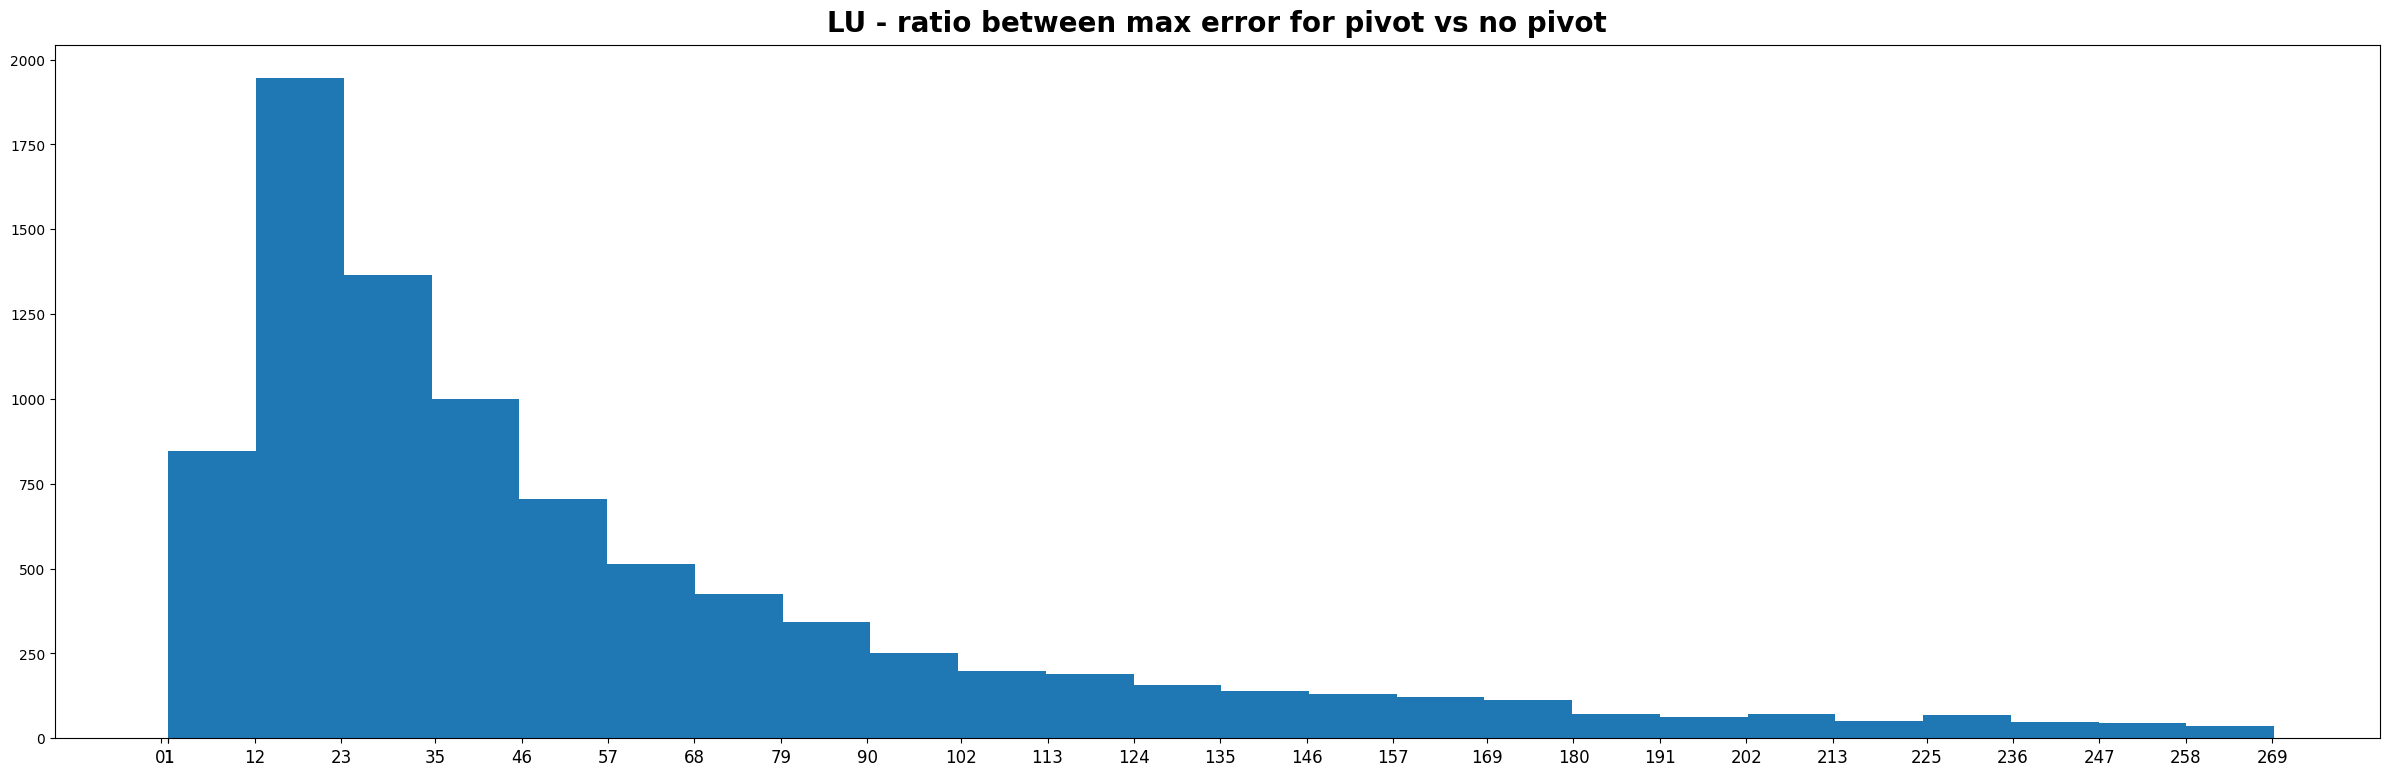

<Figure size 3000x900 with 0 Axes>

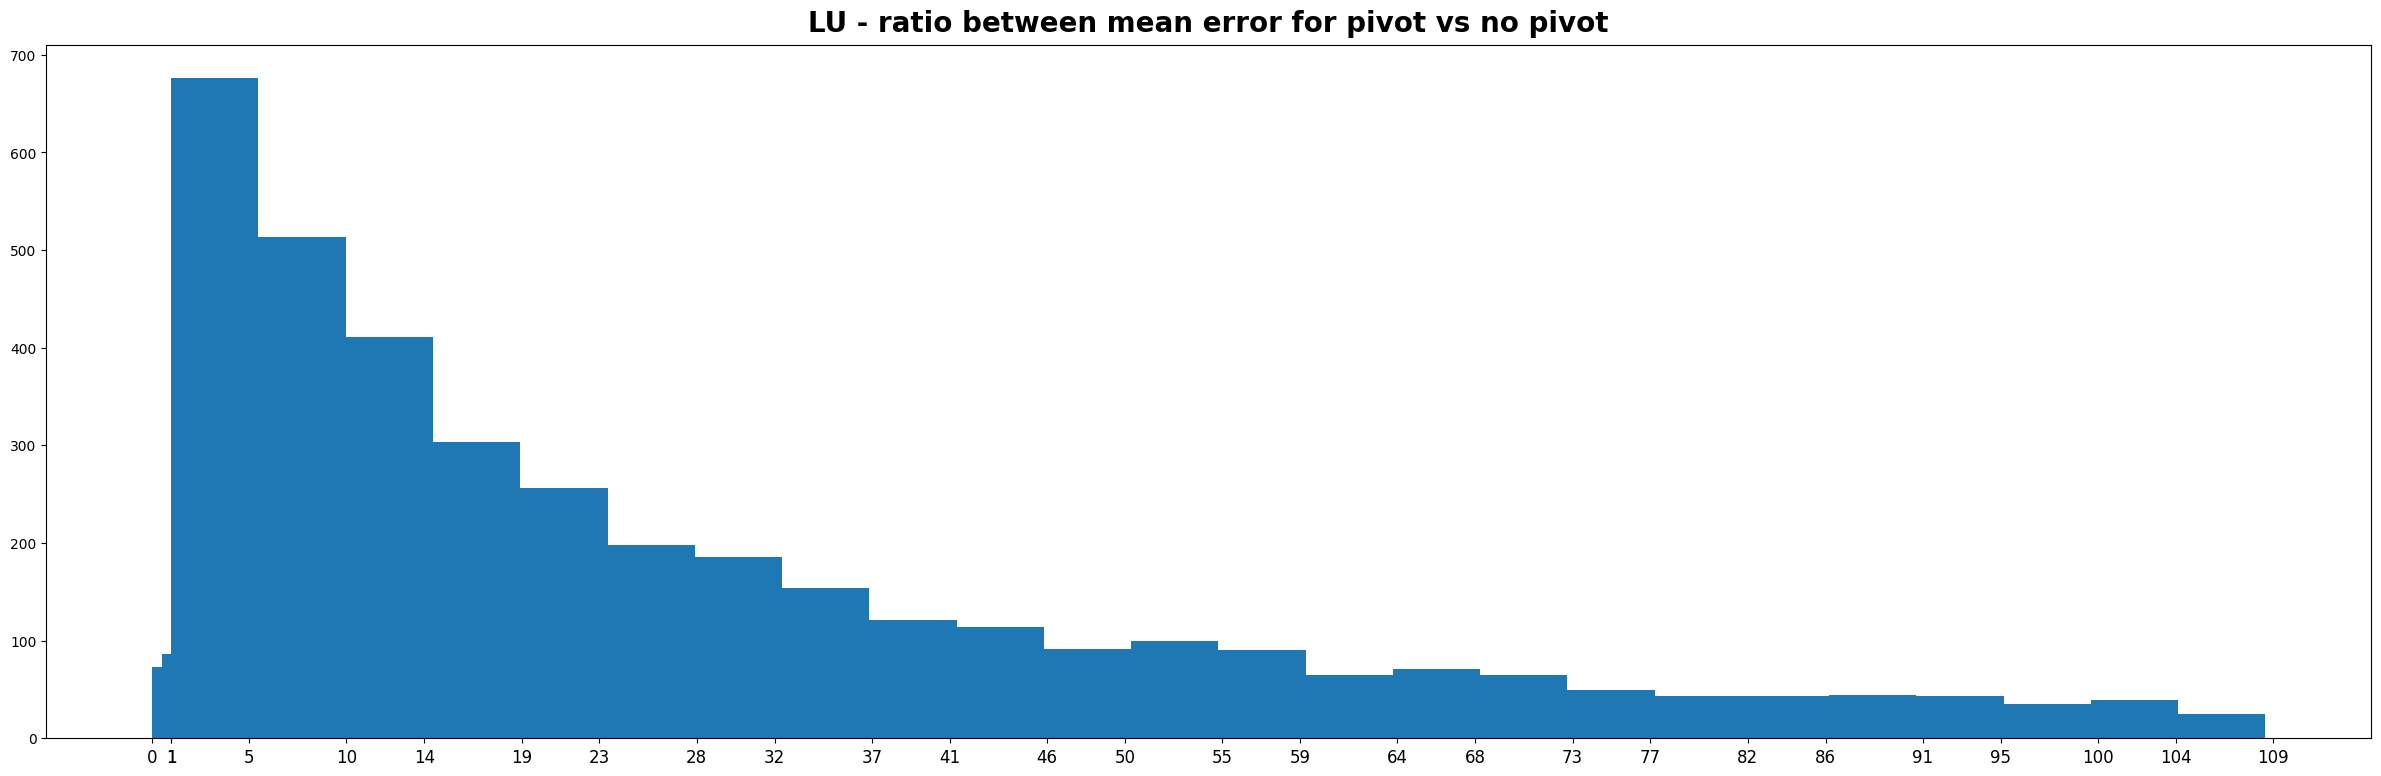

<Figure size 3000x900 with 0 Axes>

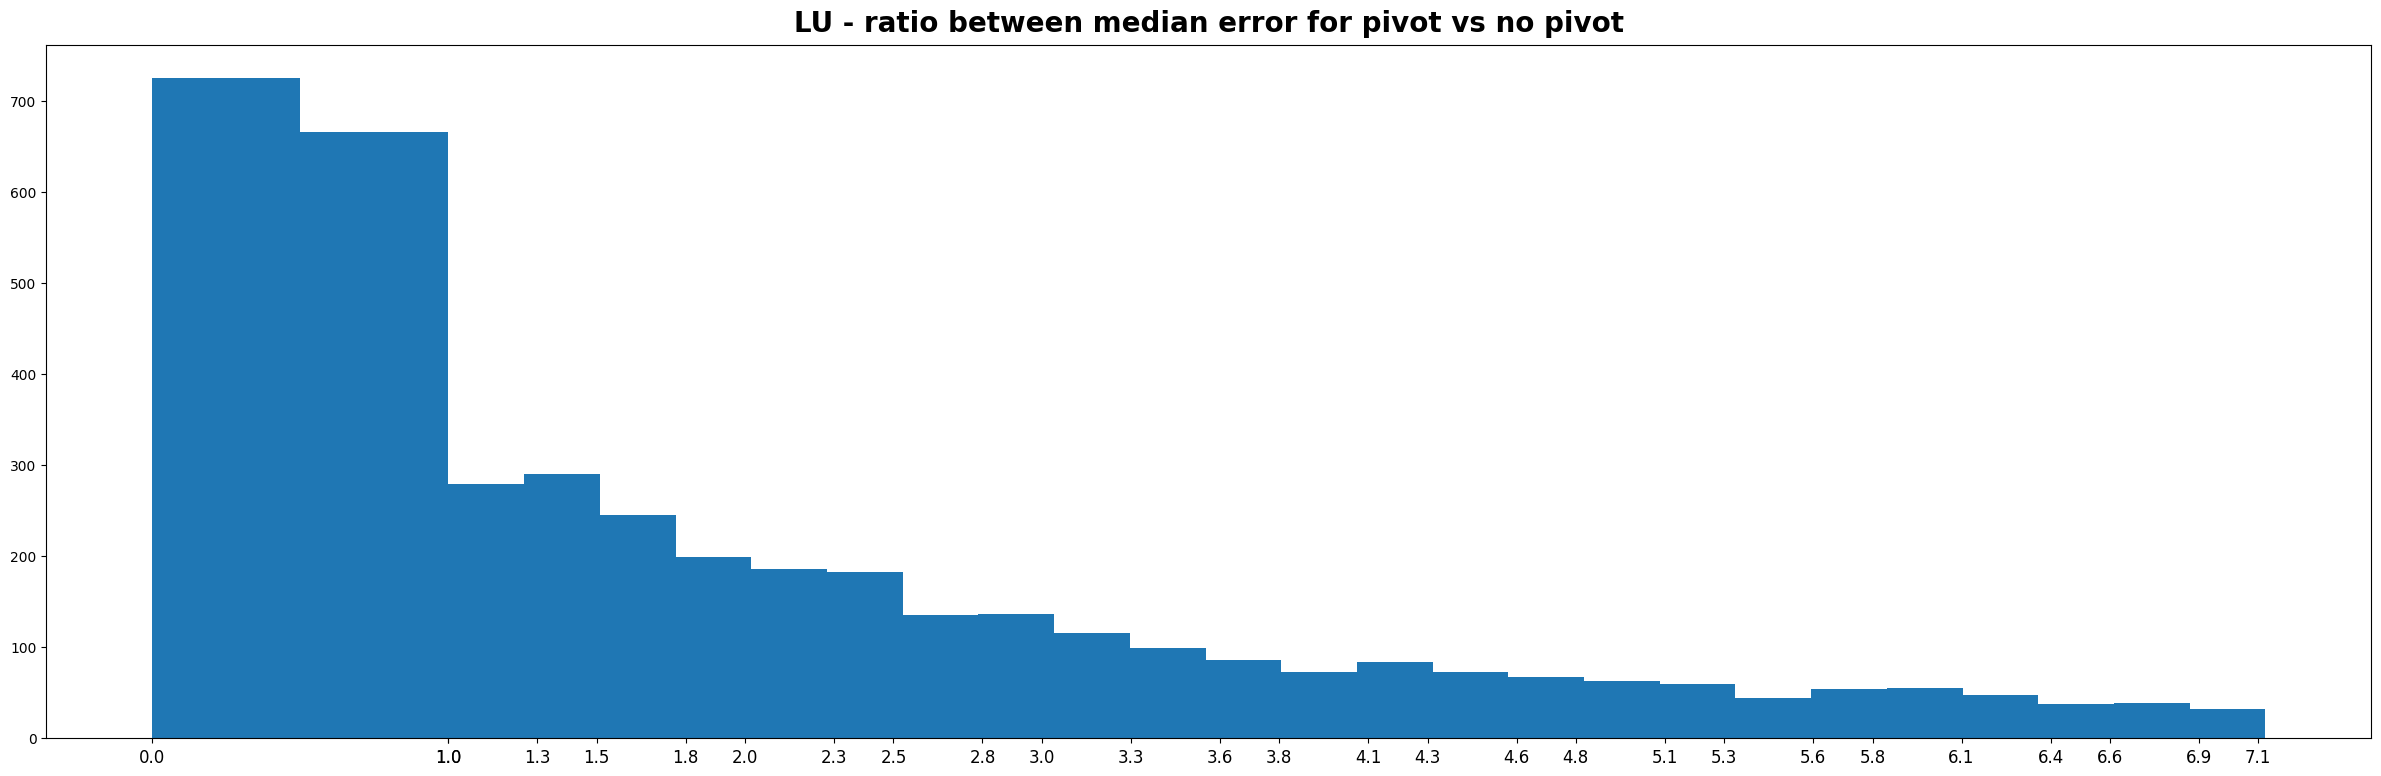

In [ ]:
labels = ["max", "mean", "median"]

def custom_rand(num, bound):
    if bound < 0.01:
        return round(num, 4)
    if bound < 0.1:
        return round(num, 3)
    if bound < 1:
        return round(num, 2)
    if bound < 15:
        return round(num, 1)
    return round(num)


for i, metric_res in enumerate([lu_pivot_max, lu_pivot_mean, lu_pivot_median]):
    lu_lims = [0, np.percentile(metric_res[:, 2], 89)]
    k = 25
    s = 15

    print(f"Lims: ({lu_lims[0]}, {round(lu_lims[1], 2)})")

    plt.figure(figsize=(30, 9))
    plt.figure(figsize=(30, 9))

    bins = np.concatenate([
        [0.0, 0.5, 1.0],
        np.linspace(1.0, lu_lims[1], k)[1:]  # more bins above 1
    ])

    plt.hist(metric_res[:, 2], bins=bins)
    plt.xticks([0.0, 1.0] + [custom_rand(bin, lu_lims[1]) for bin in bins[2:]], fontsize = 9)

    plt.title(f"LU - ratio between {labels[i]} error for pivot vs no pivot", fontsize=20, fontweight='bold', pad=10 )
    plt.plot()

    print(f"Median of {labels[i]} no pivot:", np.median(metric_res[:, 0]))
    print(f"Median of {labels[i]} with pivot", np.median(metric_res[:, 1]))

    idx_max = np.argmax(metric_res[:, 2])

    print(f"Max {labels[i]} difference:", round(np.max(metric_res[:, 2])))

In [20]:
from typing import Any
gauss_pivot_diff = defaultdict(list)

NUM_TRIALS = 10000
n = 40
zero_nonzero_cases = 0

for i in range(NUM_TRIALS):
    if i % (NUM_TRIALS//50) == 0:
        print(i, end = ' ')
        
    A = np.array([[random.random() * 15 for _ in range(n)] for _ in range(n)], dtype=np.float64)
    x = np.array([random.random() * 100 for _ in range(n)], dtype=np.float64)
    b = np.dot(A, x)

    for func, label in [[lambda x: np.max(np.abs(x)), "max"], [lambda x: np.mean(x), "mean"],
                     [lambda x: np.median(x), "median"]]:
        
        U1, b1 = gauss_numpy(A, pivoting=False, b = b)
        x_without = back_substitution(U1, b1)
        no_pivot = func(x_without - x)

        U2, b2 = gauss_numpy(A, pivoting=True, b = b)
        x_with = back_substitution(U2, b2)
        pivot = func(x_with - x)

        if pivot == 0:
            if no_pivot == 0:
                diff_i = 1
            else:
                zero_nonzero_cases += 1
                # print(f"Pivot is zero but no pivot is not: {no_pivot}")
                diff_i = no_pivot/np.finfo(np.float64).tiny
        else:
            diff_i = no_pivot/pivot

        arr = gauss_pivot_diff[label].append([no_pivot, pivot, diff_i])
    

0 200 400 600 800 1000 1200 1400 1600 1800 2000 2200 2400 2600 2800 3000 3200 3400 3600 3800 4000 4200 4400 4600 4800 5000 5200 5400 5600 5800 6000 6200 6400 6600 6800 7000 7200 7400 7600 7800 8000 8200 8400 8600 8800 9000 9200 9400 9600 9800 

In [21]:
print(f"Zero pivot but nonzero no pivot cases: {zero_nonzero_cases}/{NUM_TRIALS}")

Zero pivot but nonzero no pivot cases: 212/10000


In [22]:
gauss_pivot_max = np.array(gauss_pivot_diff["max"], dtype = np.float64)
gauss_pivot_mean = np.array(gauss_pivot_diff["mean"], dtype = np.float64)
gauss_pivot_median = np.array(gauss_pivot_diff["median"], dtype = np.float64)

Lims: (0, 107.22)
Median of max no pivot: 2.5348612098241574e-11
Median of max with pivot: 1.4495071809506044e-12
Max max difference: 72454
Lims: (0, 68.85)
Median of mean no pivot: -2.1094237467877974e-15
Median of mean with pivot: -8.881784197001253e-17
Max mean difference: 8636001019356732398136351340976803246665594674292933258146554623806690633983850268397872802904229047331798497939713720225306832713228260303681536394233624889399197459701964637731626130928425341296419652163894111878054193213905600461700850721507534945952541236826957456022376100258196207995715584
Lims: (0, 78.47)
Median of median no pivot: -9.325873406851315e-15
Median of median with pivot: 0.0
Max median difference: 3025663971649992213673886187373151713579765099051247101054739081326176669894971489269009501317353333315926809279093159902433556403834862085775673358622830160733823800108751619315439422643832623124094749024377420615029608687806412696499671254138208222118432688010043022789190843391773063890524438528


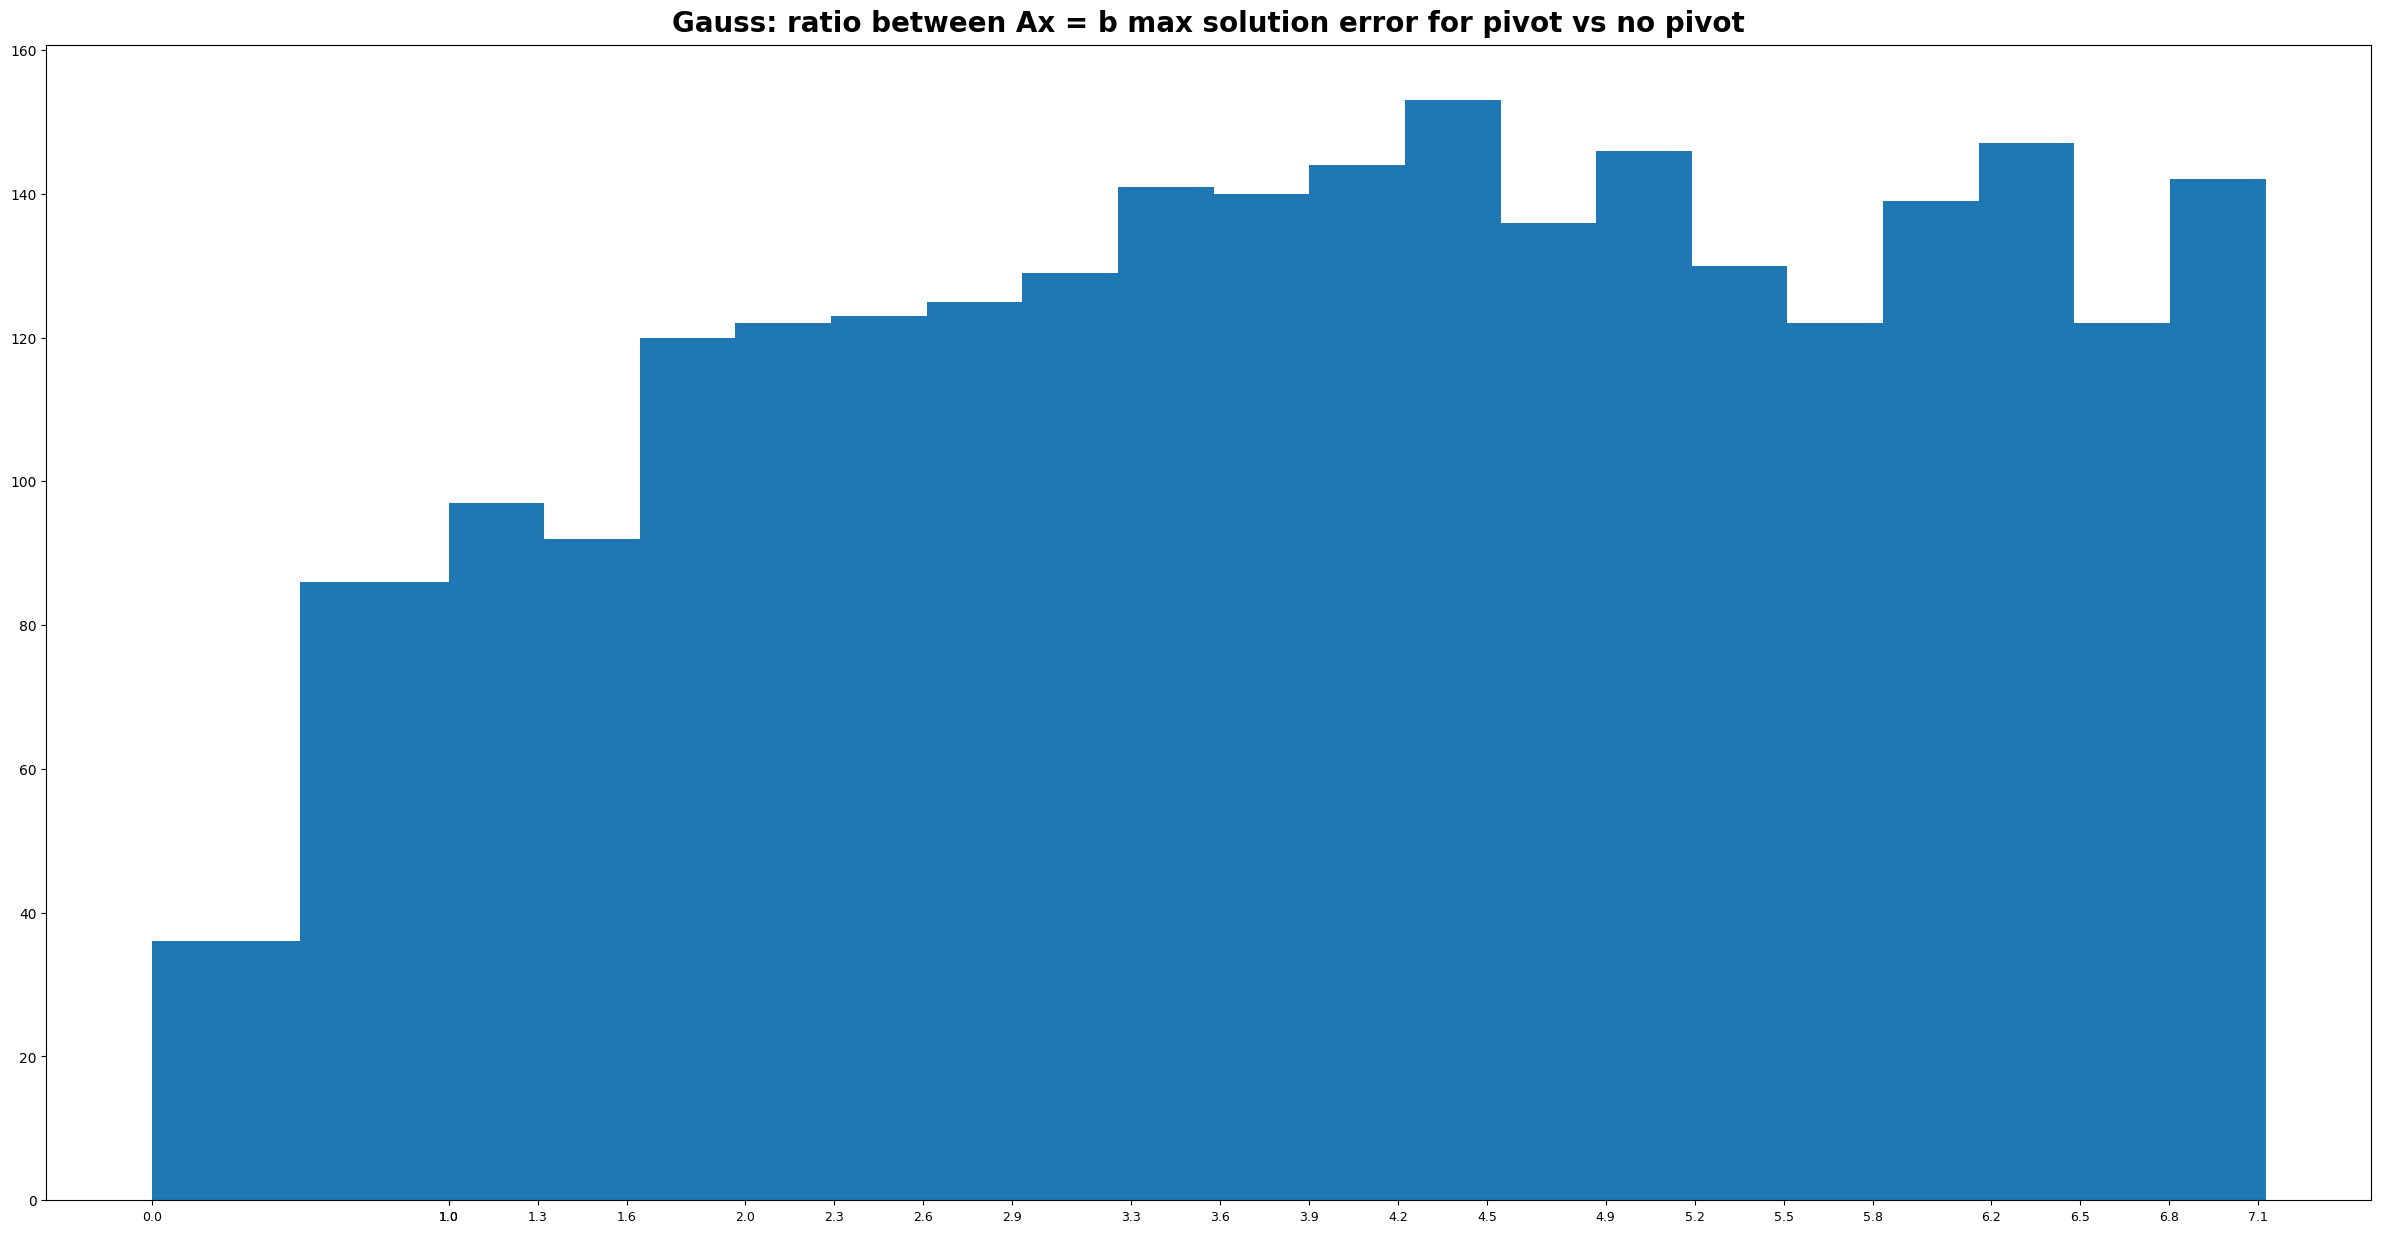

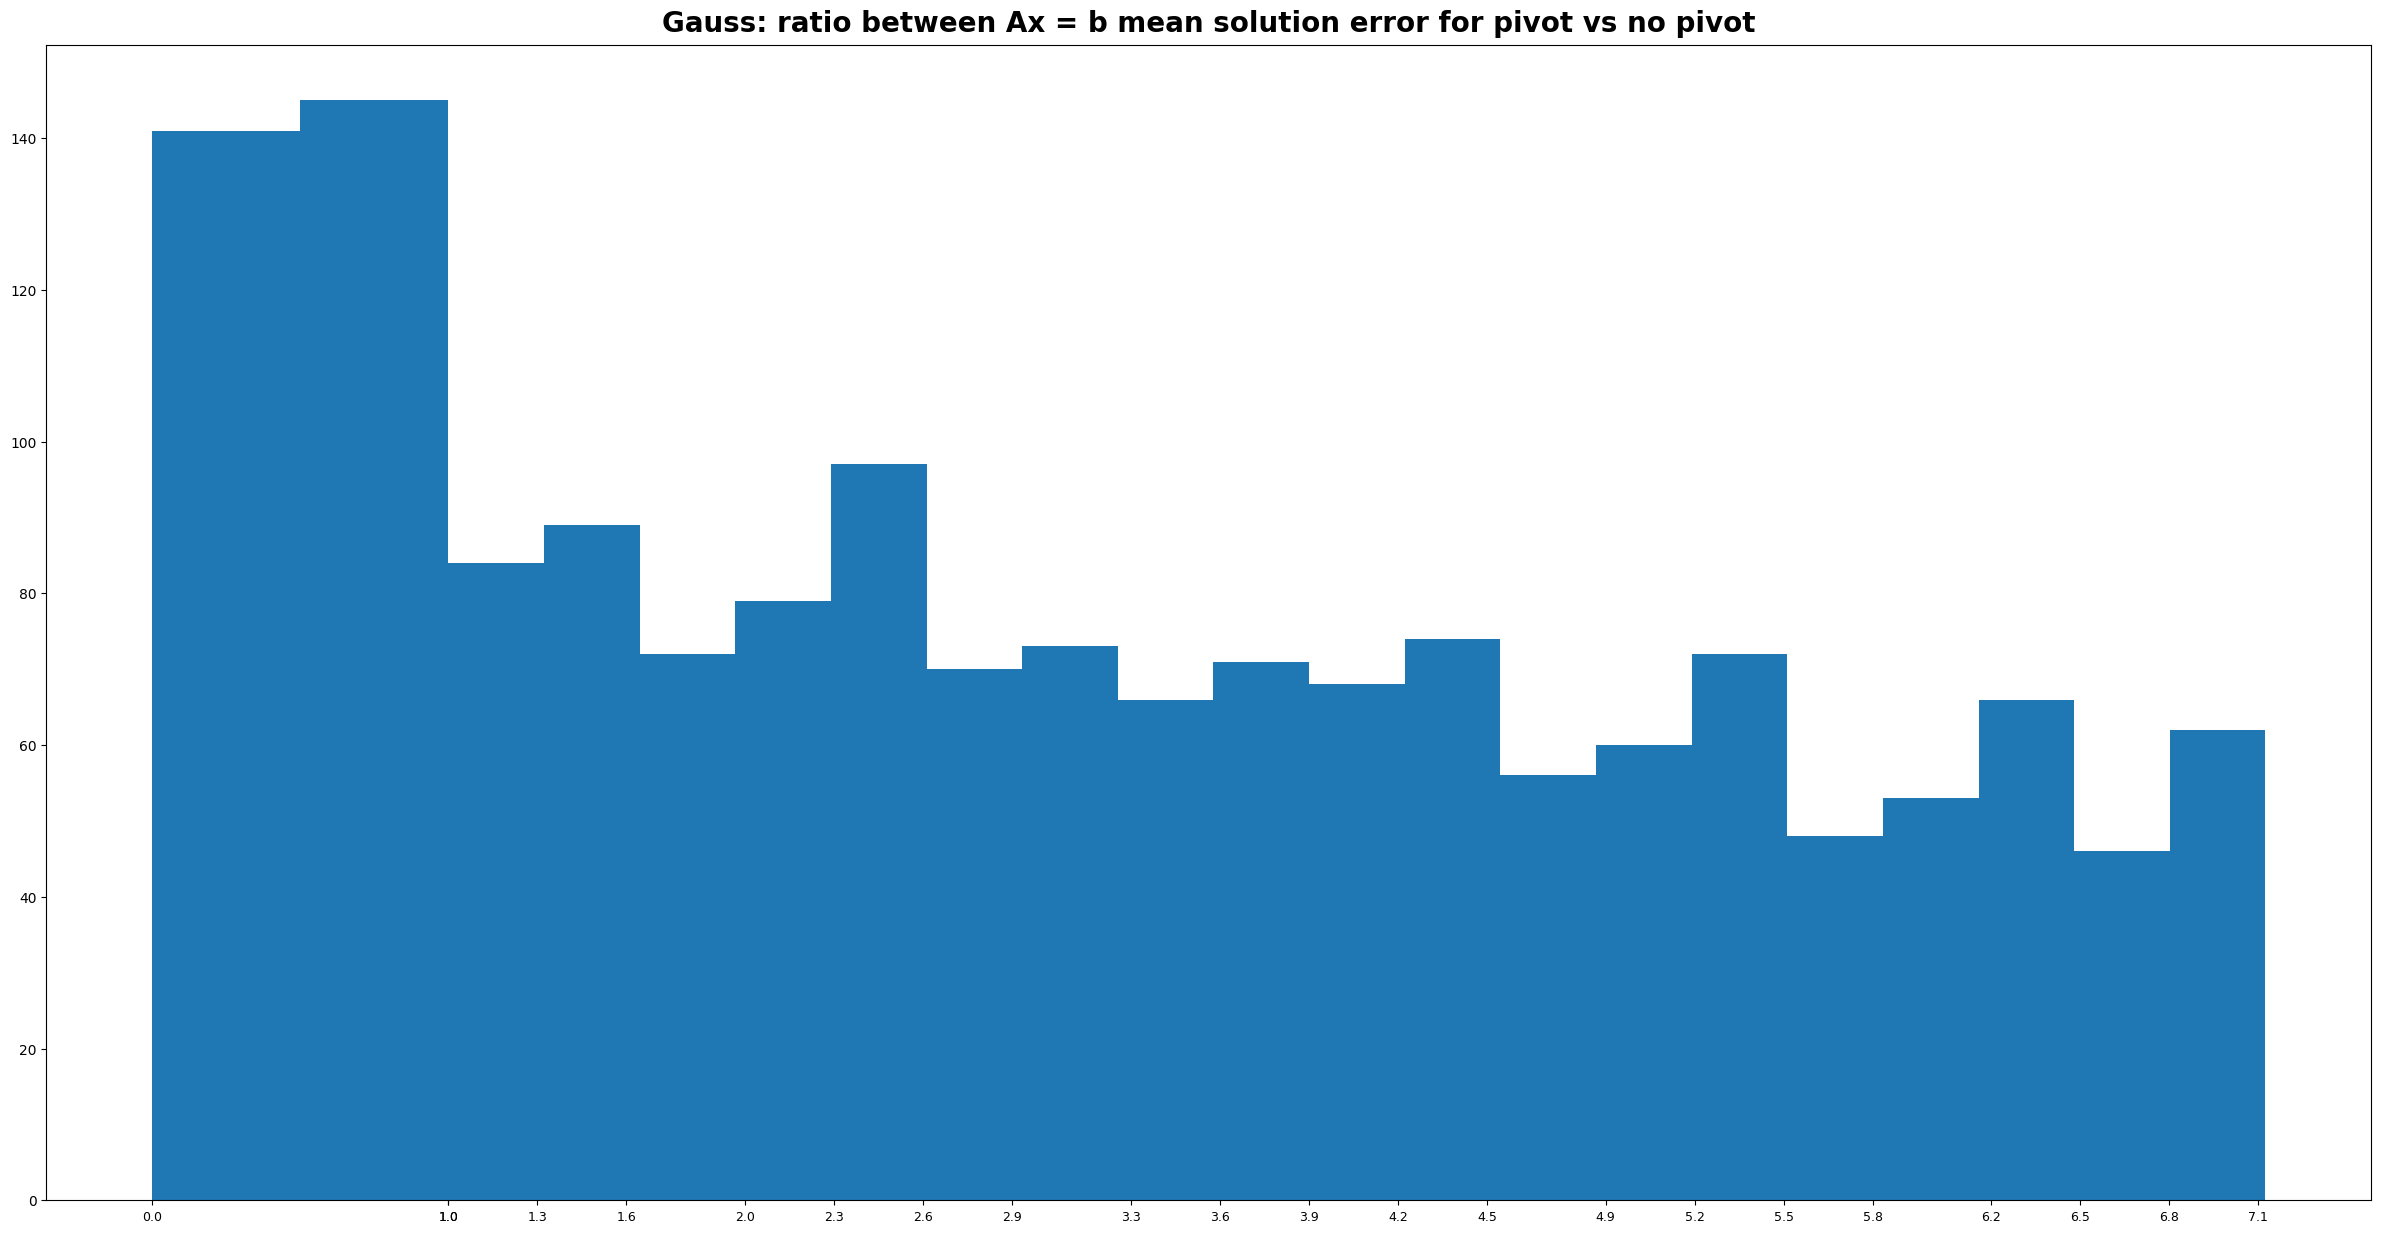

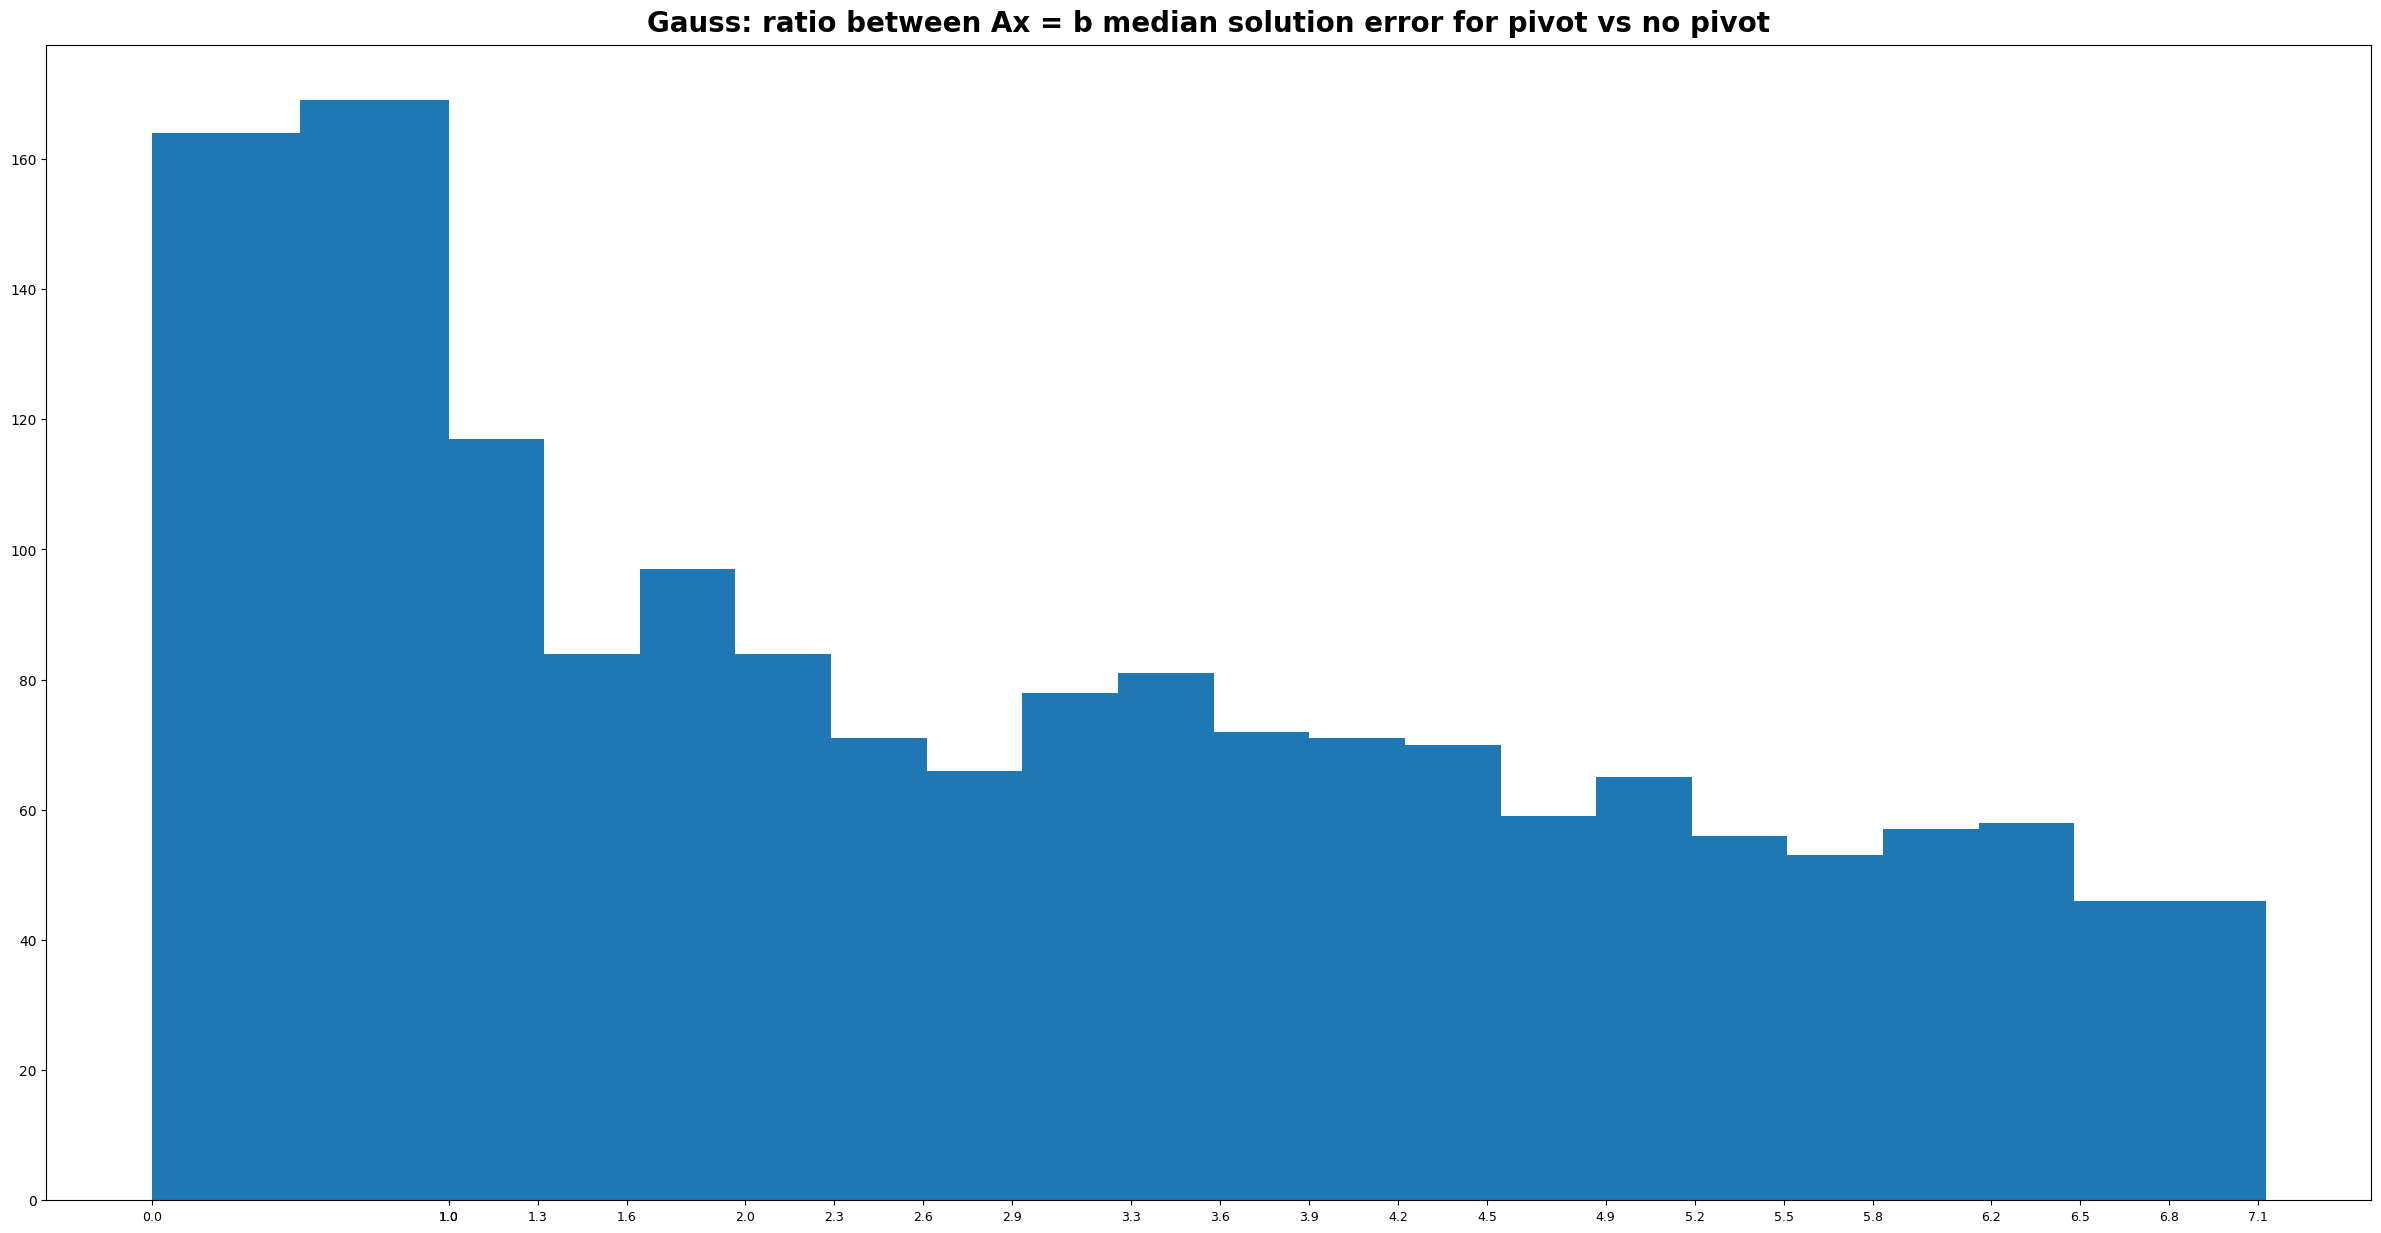

In [46]:
labels = ["max", "mean", "median"]
for i, metric_res in enumerate([gauss_pivot_max, gauss_pivot_mean, gauss_pivot_median]):
    gauss_lims = [0, np.percentile(metric_res[:, 2], 89)]
    s = 15

    print(f"Lims: ({gauss_lims[0]}, {round(gauss_lims[1], 2)})")

    plt.figure(figsize=(30, 15))
    min_val, max_val = gauss_lims[0], gauss_lims[1]

    k = 20

    bins = np.concatenate([
        [0.0, 0.5, 1.0],
        np.linspace(1.0, lu_lims[1], k)[1:]  # more bins above 1
    ])

    plt.hist(metric_res[:, 2], bins = bins)
    
    plt.xticks([0.0, 1.0] + [custom_rand(bin, lu_lims[1]) for bin in bins[2:]], fontsize = 9)
    plt.title(f"Gauss: ratio between Ax = b {labels[i]} solution error for pivot vs no pivot", fontsize=20, fontweight='bold', pad=10 )

    print(f"Median of {labels[i]} no pivot:", np.median(metric_res[:, 0]))
    print(f"Median of {labels[i]} with pivot:", np.median(metric_res[:, 1]))
    print(f"Max {labels[i]} difference:", round(np.max(metric_res[:, 2])))

### Example tests

In [ ]:
A = np.array([[random.random() * 20 for _ in range(5)] for _ in range(5)])
x = np.array([random.random() * 50 for _ in range(5)])
b = np.dot(A, x)

print("b:\n", b, sep = '')

U2, b2 = gauss_numpy(A, pivoting = False, b = b)

print("Diagonal Gauss:", U2.diagonal())
print("b2:\n", b2, sep='')

x2 = back_substitution(U2, b2)

print("x:\n", x, sep = '')
print("x_solved:\n", x2, sep = '')

b:
[1504.71035629 1123.77955778 1798.25433223 1031.54095045  625.53340245]
Diagonal Gauss: [1. 1. 1. 1. 1.]
b2:
[ 120.05963474  130.7484661  -880.00501812   10.00158101   21.44376393]
x:
[32.55559752 41.91618142  7.76523334 13.18370503 21.44376393]
x_solved:
[32.55559752 41.91618142  7.76523334 13.18370503 21.44376393]
